12.	Perform hierarchical clustering such as Agglomerative algorithm and Divisive algorithm to group several vehicles. Utilize single, complete and average linkage to define the cluster. Also draw the dendogram for this problem.

Dataset: Vehicle dataset


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel("cars_clus.xlsx")
df.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.36,0,21.5,1.8,140,101.2,67.3,172.4,2.639,13.2,28,2.828,0
1,Acura,TL,39.384,19.875,0,28.4,3.2,225,108.1,70.3,192.9,3.517,17.2,25,3.673,0
2,Acura,CL,14.114,18.225,0,$null$,3.2,225,106.9,70.6,192,3.47,17.2,26,2.647,0
3,Acura,RL,8.588,29.725,0,42,3.5,210,114.6,71.4,196.6,3.85,18,22,2.15,0
4,Audi,A4,20.397,22.255,0,23.99,1.8,150,102.6,68.2,178,2.998,16.4,27,3.015,0


In [ ]:
df_cleaned = df.replace('$null$', np.nan)
numeric_cols = [
    'sales', 'resale', 'price', 'engine_s', 'horsepow', 'wheelbas',
    'width', 'length', 'curb_wgt', 'fuel_cap', 'mpg', 'lnsales'
]

<ipython-input-10-6ba14583d841>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned = df.replace('$null$', np.nan)


In [ ]:
for col in numeric_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

In [ ]:
df_cleaned = df_cleaned.dropna(subset=numeric_cols)

In [ ]:
X = df_cleaned[numeric_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
linkage_methods = ['single', 'complete', 'average']

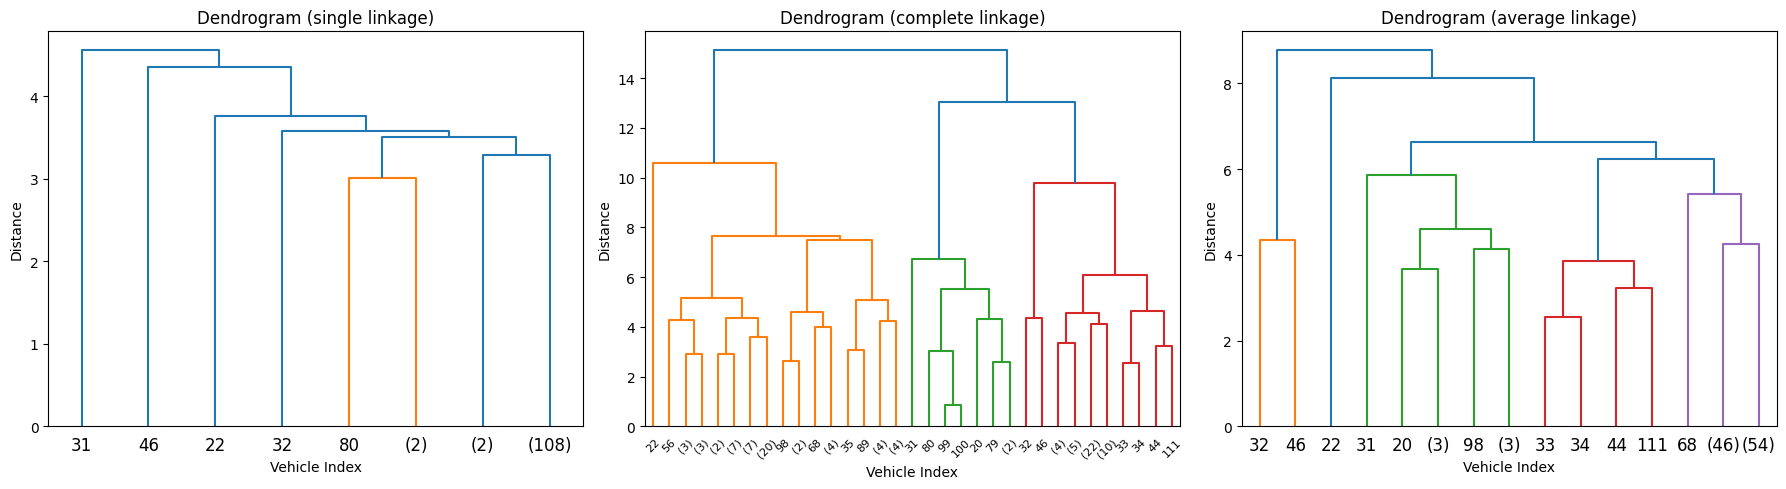

In [ ]:
plt.figure(figsize=(18, 5))
for i, method in enumerate(linkage_methods):
    plt.subplot(1, 3, i + 1)
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, truncate_mode='level', p=5)
    plt.title(f'Dendrogram ({method} linkage)')
    plt.xlabel('Vehicle Index')
    plt.ylabel('Distance')

plt.tight_layout()
plt.show()